# OSM roads 

This notebook downloads the roads (highway) from OpenStreetMap (OSM), it filters the categories of interest and then it applies that category to each segment of the noise dataset by 'join_nearest'. 
It adds to the dataframe also the distance between the segment and the road, and the length of the segment.
Finally, it saves all the data into a csv.

In [77]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse noise dataset

In [78]:
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
print(noise_streets.crs)  #CRS = Coordinate Reference System
print(noise_streets.shape)
print(noise_streets.columns.tolist())
print("Number of street segments:", len(noise_streets))

EPSG:25831
(15115, 30)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry']
Number of street segments: 15115


## Roads - OSM

In [79]:
roads = ox.features_from_place("Barcelona, Spain", tags={"highway": True}) #connects to OSM and downloads all features within Barcelona that match the tags you specify
roads = roads[roads.geometry.type == 'LineString'].to_crs(noise_streets.crs) #keeps only line geometries and reprojects to match the CRS of noise_streets (otherwise they come in EPSG:4326)
print(roads.crs)
print(roads.columns.tolist())

EPSG:25831
['geometry', 'highway', 'traffic_signals', 'traffic_signals:direction', 'button_operated', 'crossing', 'tactile_paving', 'traffic_signals:sound', 'traffic_signals:vibration', 'crossing:markings', 'crossing:signals', 'kerb', 'supervised', 'crossing:island', 'bicycle', 'source', 'traffic_signals:arrow', 'name', 'direction', 'loc_name', 'maxspeed', 'note', 'operator', 'check_date:crossing', 'source:date', 'ref', 'bench', 'bus', 'network', 'passenger_information_display', 'public_transport', 'route_ref', 'shelter', 'traffic_calming', 'speed_camera:direction', 'noref', 'noname', 'distance', 'bin', 'lit', 'name:ca', 'foot', 'destination:ref', 'traffic_sign', 'colour:ref', 'railway', 'wheelchair', 'url', 'side', 'network:short', 'network:wikidata', 'check_date:traffic_signals:sound', 'surface', 'check_date:shelter', 'website', 'alt_name', 'kerb:approach_aid', 'passenger_information_display:speech_output', 'description', 'check_date:tactile_paving', 'barrier', 'network:bus', 'networ

<Axes: >

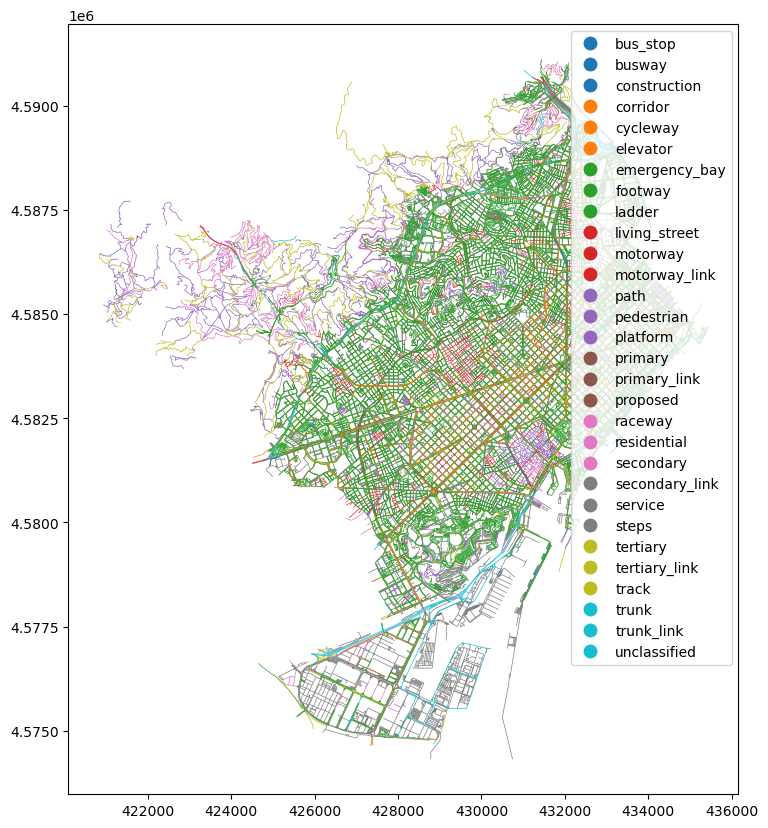

In [80]:
roads.plot(figsize=(10, 10), column='highway', linewidth=0.5, legend=True)

#https://osmnx.readthedocs.io/en/stable/user-reference.html#osmnx.features.features_from_place

## Filter roads categories

Original: 80662, Filtered: 13757


<Axes: >

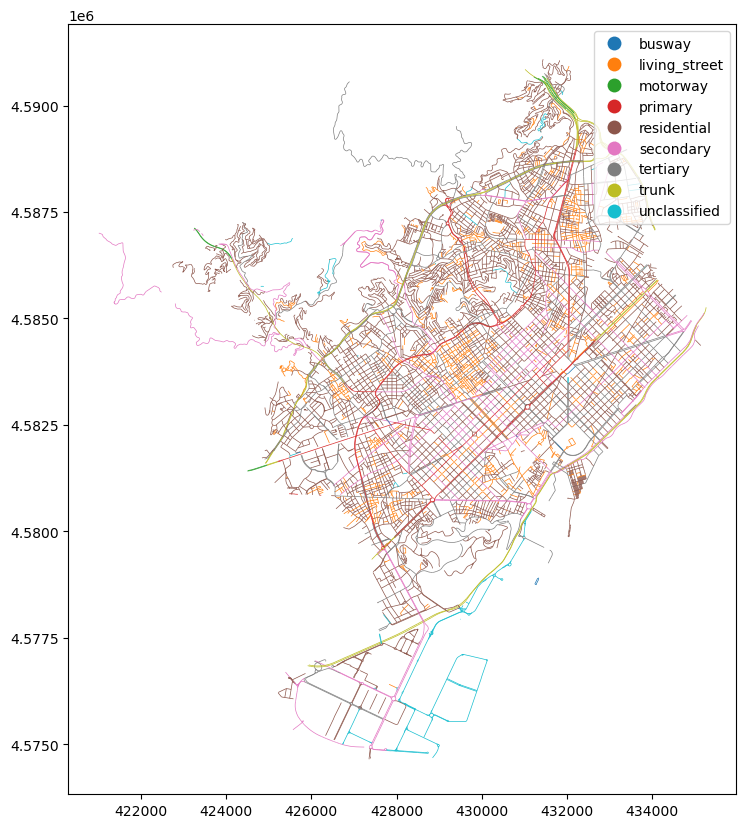

In [81]:
# Filter to only primary and secondary roads
categories = ['busway','living_street','motorway','residential','primary','secondary','tertiary','trunk','unclassified']
roads_filtered = roads[roads['highway'].isin(categories)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")
roads_filtered.plot(figsize=(10, 10), column='highway', linewidth=0.5, legend=True)

## Check max speed and width dataset

In [82]:
print(roads['maxspeed'].value_counts(dropna=False))
print("The dataset is too sparse in terms of maxspeed values, so we will not use it as a feature for now.")

maxspeed
NaN    66380
30      6870
50      4290
20      1543
10       870
80       425
60       138
40       100
70        15
15        13
90         8
7          5
100        2
4          2
1          1
Name: count, dtype: int64
The dataset is too sparse in terms of maxspeed values, so we will not use it as a feature for now.


In [83]:
print(roads['width'].value_counts(dropna=False))
print("The dataset is too sparse in terms of width values, so we will not use it as a feature for now.")

width
NaN     75543
2         958
2.5       539
1.5       483
1         413
        ...  
11.5        1
12.7        1
3.7         1
5.2         1
1.4         1
Name: count, Length: 88, dtype: int64
The dataset is too sparse in terms of width values, so we will not use it as a feature for now.


## Assign to noise street the category of the closest osm road

In [84]:
# Find the nearest road for each noise street segment
print(f"Original noise_streets: {noise_streets.shape}")
# Reset index before spatial join
noise_streets_clean = noise_streets[['geometry','TRAM','TOTAL_D','TOTAL_E','TOTAL_N']].reset_index(drop=False)
roads_clean = roads_filtered[['geometry', 'highway']].reset_index(drop=True)

dataset = gpd.sjoin_nearest(
    noise_streets_clean, 
    roads_clean,
    how='left', 
    distance_col='distance_to_road'
)

# Now filter to keep only one row per street_id if needed
dataset = dataset.drop_duplicates(subset=['index'], keep='first')
print(f"Noise streets after nearest road join: {dataset.shape}")
print(dataset.columns.tolist())

Original noise_streets: (15115, 30)
Noise streets after nearest road join: (15115, 9)
['index', 'geometry', 'TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'index_right', 'highway', 'distance_to_road']


## Create data frame

In [85]:
dataset = pd.DataFrame({
    "street_id": dataset['TRAM'],
    "noise_day": dataset['TOTAL_D'],
    "noise_evening": dataset['TOTAL_E'],
    "noise_night": dataset['TOTAL_N'],
    "road_length": dataset['geometry'].length
    ,
    "road_category": dataset['highway'], 
    "distance_to_road": dataset['distance_to_road']    
}).fillna(0) #fillna(0) to replace any NaN values (which indicate no signals or POIs in that segment) with 0
dataset.head(10)

,street_id,noise_day,noise_evening,noise_night,road_length,road_category,distance_to_road
0,T04719W,70 - 75 dB(A),65 - 70 dB(A),60 - 65 dB(A),48.661095,residential,0.000000
1,T19941Z,45 - 50 dB(A),45 - 50 dB(A),< 40 dB(A),87.202693,living_street,0.006296
2,T18111R,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),79.934562,residential,0.000000
3,T03222Y,60 - 65 dB(A),55 - 60 dB(A),60 - 65 dB(A),77.367711,living_street,0.000000
4,T17625I,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),107.679649,residential,0.000000
5,T05360P,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),91.759758,residential,0.000000
6,T08863T,50 - 55 dB(A),50 - 55 dB(A),45 - 50 dB(A),86.869284,residential,0.000000
7,T00236S,45 - 50 dB(A),45 - 50 dB(A),40 - 45 dB(A),57.158529,residential,0.000000
8,T13009A,55 - 60 dB(A),55 - 60 dB(A),50 - 55 dB(A),147.700343,residential,0.000000
9,T11921P,60 - 65 dB(A),55 - 60 dB(A),50 - 55 dB(A),61.576419,residential,0.000000


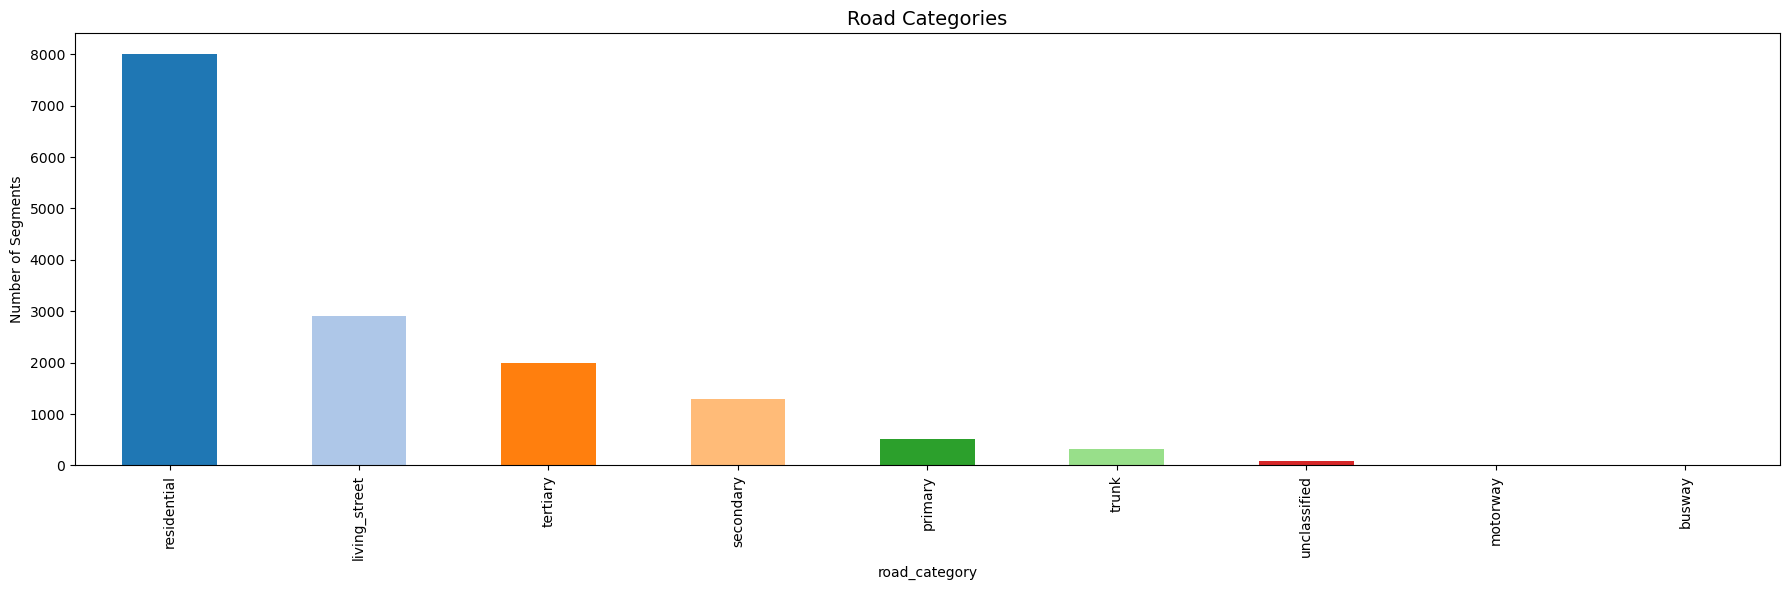

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = dataset['road_category'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

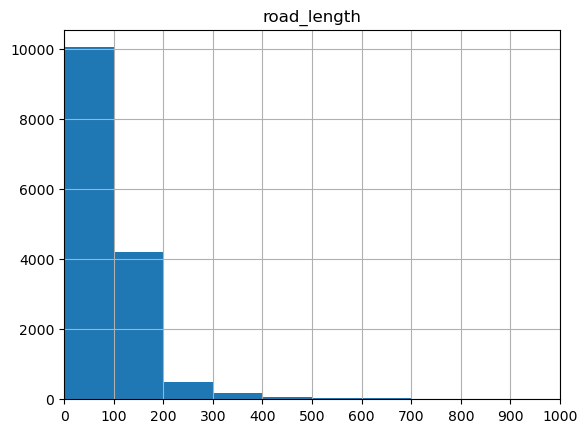

In [87]:
dataset.hist("road_length",bins=np.arange(0, 1001, 100))
plt.xlim(0, 1000)
plt.xticks(np.arange(0, 1001, 100))  # Step of 100
plt.show()

## Export dataset to CSV

In [89]:
import os
output_dir = "../../data/processed"
os.makedirs(output_dir, exist_ok=True)
dataset.drop(columns=['distance_to_road'], inplace=True) #dropping distance_to_road column
dataset.to_csv(os.path.join(output_dir, "osm_roads_features.csv"), index=False)
print("Exported osm_roads_features.csv")

Exported osm_roads_features.csv
